# Six-parameter PFF data for the hybrid CNN

This notebook uses the final six-parameter PFF equation from the original
training-data notebook:

\[
s(E)=a_1e^{-a_2E}
+a_3\exp\left[
-\frac{(E-a_4)^2}{a_5E+a_6/E}
\right].
\]

For every generated spectrum, the detector response is kept as 200 independent
effective measurements and split into:

- `fine_image`: channels 0–191 reshaped to `(4, 48, 1)`
- `coarse_pixels`: channels 192–199 kept as an independent `(8,)` vector
- `spectrum`: the normalized 50-bin target

The final arrays can be passed directly to the hybrid Keras model using:

```python
model.fit(
    {
        "fine_image": X_train_fine,
        "coarse_pixels": X_train_coarse,
    },
    y_train,
)
```

In [34]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## Configuration

In [ ]:
# Path to the same 200 x 200 DRM CSV used by the original notebook.
DRM_CSV_PATH = Path("res/drm/200x200.csv")

NUM_ENERGY_BINS = 50  # matches best_model_6param_hybrid_n50.keras
NUM_SAMPLES = 100_000
VAL_SAMPLES = 5_000
BATCH_GENERATION_SIZE = 5_000
SEED = 42

# Preserve the original notebook behavior by default.
# Set True to add a Gaussian approximation to Poisson counting noise.
ADD_COUNTING_NOISE = True

# Save all model-ready arrays at the end.
OUTPUT_PATH = Path("six_param_hybrid_training_data.npz")

assert 200 % NUM_ENERGY_BINS == 0
assert 0 < VAL_SAMPLES < NUM_SAMPLES

## Load and bin the detector response matrix

In [36]:
# The original CSV is assumed to have:
#   rows    = 200 true-energy bins
#   columns = 200 detector channels
drm_200 = np.loadtxt(DRM_CSV_PATH, delimiter=",").astype(np.float32)

if drm_200.shape != (200, 200):
    raise ValueError(
        f"Expected a (200, 200) DRM, but received {drm_200.shape}."
    )

bins_per_group = 200 // NUM_ENERGY_BINS

# Average every four consecutive true-energy rows:
#   (200 energy bins, 200 detector channels)
#       -> (50 energy bins, 200 detector channels)
drm_energy_detector = drm_200.reshape(
    NUM_ENERGY_BINS,
    bins_per_group,
    200,
).mean(axis=1).astype(np.float32)

# Match the original notebook's energy-bin construction exactly.
energy_bins_200 = np.linspace(0.25, 50.0, 200, dtype=np.float32)
energy_bins = energy_bins_200.reshape(
    NUM_ENERGY_BINS,
    bins_per_group,
).mean(axis=1).astype(np.float32)

print("Original DRM:", drm_200.shape)
print("Binned DRM:", drm_energy_detector.shape)
print("Energy bins:", energy_bins.shape)
print("Energy range:", float(energy_bins[0]), "to", float(energy_bins[-1]), "MeV")

Original DRM: (200, 200)
Binned DRM: (100, 200)
Energy bins: (100,)
Energy range: 0.375 to 49.875 MeV


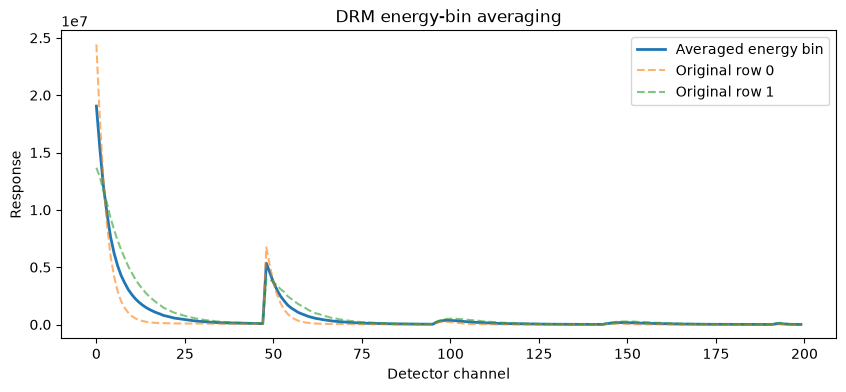

In [37]:
# Compare the first averaged response with the four original rows.
plt.figure(figsize=(10, 4))
plt.plot(drm_energy_detector[0], label="Averaged energy bin", linewidth=2)
for row in range(bins_per_group):
    plt.plot(drm_200[row], "--", alpha=0.6, label=f"Original row {row}")
plt.xlabel("Detector channel")
plt.ylabel("Response")
plt.title("DRM energy-bin averaging")
plt.legend()
plt.show()

## Six-parameter PFF equation and bounded parameter sampling

In [38]:
def original_pff_func(
    energy: np.ndarray,
    params: np.ndarray,
) -> np.ndarray:
    """
    Evaluate one or many six-parameter PFF spectra.

    energy:
        shape (M,)

    params:
        shape (6,) or (N, 6)

    returns:
        shape (M,) or (N, M)
    """
    energy = np.asarray(energy, dtype=np.float64)
    params = np.asarray(params, dtype=np.float64)

    single_sample = params.ndim == 1
    if single_sample:
        params = params[np.newaxis, :]

    if params.ndim != 2 or params.shape[1] != 6:
        raise ValueError("params must have shape (6,) or (N, 6).")

    E = energy[np.newaxis, :]
    a1, a2, a3, a4, a5, a6 = (
        params[:, j, np.newaxis] for j in range(6)
    )

    denominator = a5 * E + a6 / E
    denominator = np.maximum(denominator, 1e-12)

    spectra = (
        a1 * np.exp(-a2 * E)
        + a3 * np.exp(-((E - a4) ** 2) / denominator)
    )

    return spectra[0] if single_sample else spectra


# Columns are [mean, standard deviation, lower bound, upper bound].
# These are the final six-parameter ranges from the original notebook.
PFF6_PARAM_RANGES = np.array(
    [
        [150.0, 100.0, 50.0, 250.0],   # a1
        [0.3,     1.0,  0.01,   2.0],  # a2
        [20.0,   10.0,  0.0,   50.0],  # a3
        [20.0,   25.0,  1.0,   49.0],  # a4
        [0.5,     1.0,  1e-6,  10.0],  # a5
        [100.0, 500.0,  1e-6, 1e4],    # a6
    ],
    dtype=np.float64,
)


def sample_bounded_normal_parameters(
    n_samples: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Vectorized rejection sampling for the six PFF parameters."""
    means = PFF6_PARAM_RANGES[:, 0]
    stds = PFF6_PARAM_RANGES[:, 1]
    lower = PFF6_PARAM_RANGES[:, 2]
    upper = PFF6_PARAM_RANGES[:, 3]

    params = rng.normal(means, stds, size=(n_samples, 6))
    invalid = (params < lower) | (params > upper)

    while invalid.any():
        redraw = rng.normal(means, stds, size=(n_samples, 6))
        params = np.where(invalid, redraw, params)
        invalid = (params < lower) | (params > upper)

    return params

## Generate raw spectra and 200-channel detector responses

In [39]:
def generate_six_param_dataset(
    drm_energy_detector: np.ndarray,
    energy_bins: np.ndarray,
    n_samples: int,
    rng: np.random.Generator,
    batch_size: int = 5_000,
    add_counting_noise: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate raw detector responses and six-parameter spectra.

    Returns
    -------
    detector_responses:
        (n_samples, 200), float32

    spectra:
        (n_samples, n_energy_bins), float32

    parameters:
        (n_samples, 6), float32
    """
    n_energy_bins, n_detector_channels = drm_energy_detector.shape

    detector_responses = np.empty(
        (n_samples, n_detector_channels),
        dtype=np.float32,
    )
    spectra = np.empty(
        (n_samples, n_energy_bins),
        dtype=np.float32,
    )
    parameters = np.empty(
        (n_samples, 6),
        dtype=np.float32,
    )

    for start in range(0, n_samples, batch_size):
        stop = min(start + batch_size, n_samples)
        current_n = stop - start

        params_batch = sample_bounded_normal_parameters(current_n, rng)
        spectra_batch = original_pff_func(
            energy_bins,
            params_batch,
        )

        # (batch, 50) @ (50, 200) -> (batch, 200)
        responses_batch = spectra_batch @ drm_energy_detector

        if add_counting_noise:
            sigma = np.sqrt(np.maximum(responses_batch, 1e-8))
            sigma *= 5.0
            responses_batch = (
                responses_batch
                + rng.standard_normal(responses_batch.shape) * sigma
            )
            responses_batch = np.clip(responses_batch, 0.0, None)

        detector_responses[start:stop] = responses_batch.astype(np.float32)
        spectra[start:stop] = spectra_batch.astype(np.float32)
        parameters[start:stop] = params_batch.astype(np.float32)

    return detector_responses, spectra, parameters


rng = np.random.default_rng(SEED)

X_raw, y_raw, pff6_parameters = generate_six_param_dataset(
    drm_energy_detector=drm_energy_detector,
    energy_bins=energy_bins,
    n_samples=NUM_SAMPLES,
    rng=rng,
    batch_size=BATCH_GENERATION_SIZE,
    add_counting_noise=ADD_COUNTING_NOISE,
)

print("Raw detector responses:", X_raw.shape)
print("Raw spectrum targets:", y_raw.shape)
print("Six-parameter values:", pff6_parameters.shape)

Raw detector responses: (100000, 200)
Raw spectrum targets: (100000, 100)
Six-parameter values: (100000, 6)


## Normalize exactly for the hybrid spectrum model

In [40]:
def l1_normalize_rows(array: np.ndarray) -> np.ndarray:
    row_sums = array.sum(axis=1, keepdims=True)
    return (
        array / np.maximum(row_sums, 1e-12)
    ).astype(np.float32)


# The hybrid model's softmax output represents a probability distribution,
# so both detector responses and spectrum targets are L1-normalized.
X_l1 = l1_normalize_rows(X_raw)
y = l1_normalize_rows(y_raw)

# The generated samples are independent and identically distributed, so the
# final VAL_SAMPLES rows can be used as validation data.
train_stop = NUM_SAMPLES - VAL_SAMPLES

# Fit z-score statistics using training data only.
norm_mean = X_l1[:train_stop].mean(axis=0).astype(np.float32)
norm_std = np.maximum(
    X_l1[:train_stop].std(axis=0),
    1e-8,
).astype(np.float32)

X_normalized = (
    (X_l1 - norm_mean) / norm_std
).astype(np.float32)

print("Normalized detector data:", X_normalized.shape)
print("Target row sums:", y[:3].sum(axis=1))

Normalized detector data: (100000, 200)
Target row sums: [1.        1.        1.0000001]


## Split the 200 measurements into `(4, 48, 1)` and `(8,)` branches

In [41]:
def split_detector_input(
    X: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Split each 200-channel detector response without repeating any values.

    First 192 channels:
        (N, 192) -> (N, 4, 48, 1)

    Final eight channels:
        (N, 8)
    """
    if X.ndim != 2 or X.shape[1] != 200:
        raise ValueError(
            f"Expected X with shape (N, 200), received {X.shape}."
        )

    fine_image = X[:, :192].reshape(
        -1,
        4,
        48,
        1,
    ).astype(np.float32)

    coarse_pixels = X[:, 192:200].astype(np.float32)

    return fine_image, coarse_pixels


X_fine, X_coarse = split_detector_input(X_normalized)

X_train_fine = X_fine[:train_stop]
X_train_coarse = X_coarse[:train_stop]
y_train = y[:train_stop]

X_val_fine = X_fine[train_stop:]
X_val_coarse = X_coarse[train_stop:]
y_val = y[train_stop:]

print("X_train_fine:", X_train_fine.shape)
print("X_train_coarse:", X_train_coarse.shape)
print("y_train:", y_train.shape)
print()
print("X_val_fine:", X_val_fine.shape)
print("X_val_coarse:", X_val_coarse.shape)
print("y_val:", y_val.shape)

X_train_fine: (95000, 4, 48, 1)
X_train_coarse: (95000, 8)
y_train: (95000, 100)

X_val_fine: (5000, 4, 48, 1)
X_val_coarse: (5000, 8)
y_val: (5000, 100)


## Inspect generated examples

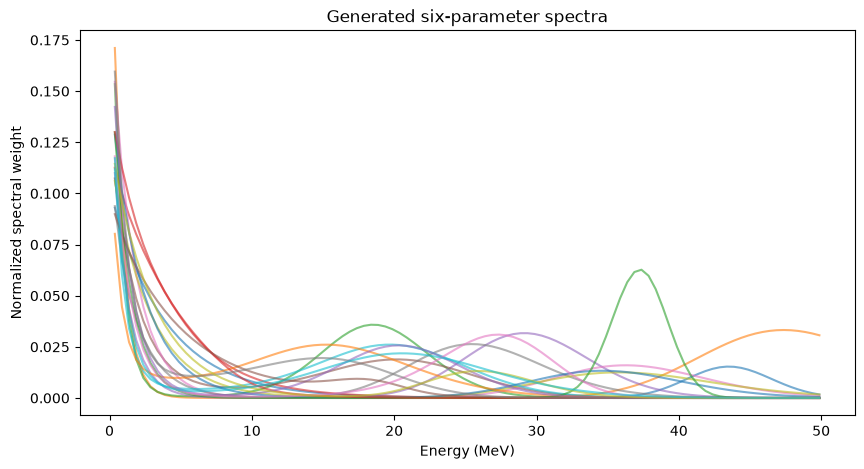

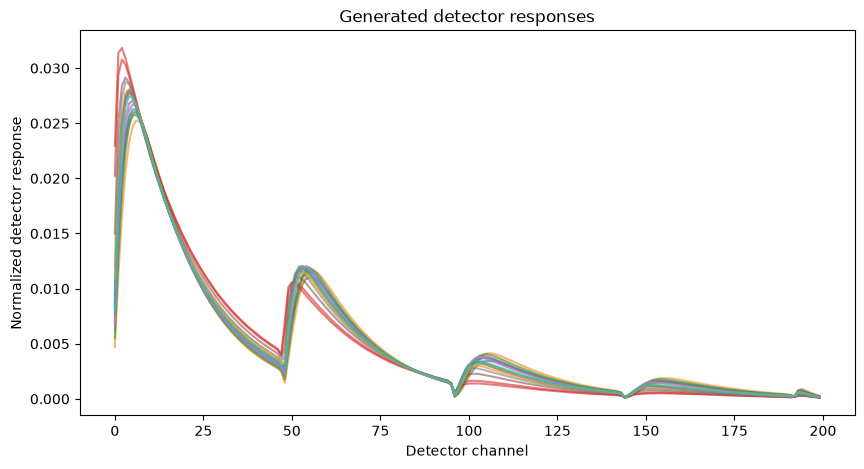

In [42]:
n_plot = min(20, NUM_SAMPLES)

plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(energy_bins, y[i], alpha=0.6)
plt.xlabel("Energy (MeV)")
plt.ylabel("Normalized spectral weight")
plt.title("Generated six-parameter spectra")
plt.show()

plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(X_l1[i], alpha=0.6)
plt.xlabel("Detector channel")
plt.ylabel("Normalized detector response")
plt.title("Generated detector responses")
plt.show()

## Save model-ready arrays

In [43]:
np.savez(
    OUTPUT_PATH,
    X_train_fine=X_train_fine,
    X_train_coarse=X_train_coarse,
    y_train=y_train,
    X_val_fine=X_val_fine,
    X_val_coarse=X_val_coarse,
    y_val=y_val,
    norm_mean=norm_mean,
    norm_std=norm_std,
    energy_bins=energy_bins,
    pff6_parameters=pff6_parameters,
)

print(f"Saved model-ready data to: {OUTPUT_PATH.resolve()}")

Saved model-ready data to: C:\Users\aayan\OneDrive\Documents\GitHub\SAS-Analysis-Laser\six_param_hybrid_training_data.npz


## Fit the existing hybrid model

In [44]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Import only the function needed instead of using import *
from train_cnn_hybrid import build_model


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

NUM_ENERGY_BINS = 100
MAX_EPOCHS = 200
BATCH_SIZE = 256

BEST_MODEL_PATH = (
    f"best_model_6param_hybrid_n{NUM_ENERGY_BINS}.keras"
)

HISTORY_CSV_PATH = (
    f"training_history_6param_hybrid_n{NUM_ENERGY_BINS}.csv"
)

HISTORY_JSON_PATH = (
    f"training_history_6param_hybrid_n{NUM_ENERGY_BINS}.json"
)

SUMMARY_PATH = (
    f"training_summary_6param_hybrid_n{NUM_ENERGY_BINS}.json"
)


# ------------------------------------------------------------------
# Build and compile model
# ------------------------------------------------------------------

model = build_model(NUM_ENERGY_BINS)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0,
    ),
    loss="mse",
    metrics=["mae"],
)


# ------------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------------

callbacks = [

    # Save the model only when validation loss improves.
    # At the end, this file contains the model from the best epoch.
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    # Stop training when validation loss has not improved for 30 epochs.
    # Also put the best weights back into the in-memory model.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=30,
        restore_best_weights=True,
        verbose=1,
    ),

    # Reduce the learning rate when validation improvement stalls.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=10,
        min_lr=1e-5,
        verbose=1,
    ),

    # Write the loss and metrics to a CSV file after every epoch.
    tf.keras.callbacks.CSVLogger(
        HISTORY_CSV_PATH,
    ),
]


# ------------------------------------------------------------------
# Train
# ------------------------------------------------------------------

history = model.fit(
    {
        "fine_image": X_train_fine,
        "coarse_pixels": X_train_coarse,
    },
    y_train,

    validation_data=(
        {
            "fine_image": X_val_fine,
            "coarse_pixels": X_val_coarse,
        },
        y_val,
    ),

    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


# ------------------------------------------------------------------
# Find the best epoch
# ------------------------------------------------------------------

best_epoch_index = int(
    np.argmin(history.history["val_loss"])
)

# Add one because Python indexes epochs starting at zero.
best_epoch = best_epoch_index + 1

best_val_loss = float(
    history.history["val_loss"][best_epoch_index]
)

best_val_mae = float(
    history.history["val_mae"][best_epoch_index]
)

best_train_loss = float(
    history.history["loss"][best_epoch_index]
)

best_train_mae = float(
    history.history["mae"][best_epoch_index]
)


# ------------------------------------------------------------------
# Save training history
# ------------------------------------------------------------------

# Save every epoch's metrics as JSON.
with open(HISTORY_JSON_PATH, "w") as file:
    json.dump(
        history.history,
        file,
        indent=2,
    )

# This is optional because CSVLogger already creates a CSV,
# but it ensures the completed history is also stored.
pd.DataFrame(history.history).to_csv(
    HISTORY_CSV_PATH,
    index_label="epoch_index",
)


# ------------------------------------------------------------------
# Save a summary of the best epoch
# ------------------------------------------------------------------

training_summary = {
    "num_energy_bins": NUM_ENERGY_BINS,
    "epochs_completed": len(history.history["loss"]),
    "best_epoch": best_epoch,
    "best_train_loss": best_train_loss,
    "best_validation_loss": best_val_loss,
    "best_train_mae": best_train_mae,
    "best_validation_mae": best_val_mae,
    "best_model_path": BEST_MODEL_PATH,
}

with open(SUMMARY_PATH, "w") as file:
    json.dump(
        training_summary,
        file,
        indent=2,
    )


print("\nTraining complete")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.8f}")
print(f"Best validation MAE: {best_val_mae:.8f}")
print(f"Best model saved to: {BEST_MODEL_PATH}")
print(f"Training history saved to: {HISTORY_CSV_PATH}")
print(f"Training summary saved to: {SUMMARY_PATH}")

TensorFlow: 2.21.0
GPUs: []
Epoch 1/200
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.2288e-05 - mae: 0.0042
Epoch 1: val_loss improved from None to 0.00004, saving model to best_model_6param_hybrid_n100.keras

Epoch 1: finished saving model to best_model_6param_hybrid_n100.keras
372/372 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - loss: 7.2276e-05 - mae: 0.0042 - val_loss: 3.8720e-05 - val_mae: 0.0033 - learning_rate: 0.0010
Epoch 2/200
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.4678e-06 - mae: 0.0017
Epoch 2: val_loss improved from 0.00004 to 0.00002, saving model to best_model_6param_hybrid_n100.keras

Epoch 2: finished saving model to best_model_6param_hybrid_n100.keras
372/372 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - loss: 8.4712e-06 - mae: 0.0017 - val_loss: 2.3212e-05 - val_mae: 0.0019 - learning_rate: 0.0010
Epoch 3/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 6.3741e-06 - mae: 0.0014
Epoch 3: val_loss improved from 0.00002 to 0.00001, saving model to best_model_6pa

## Shapes produced

For `NUM_SAMPLES = 100000` and `VAL_SAMPLES = 5000`:

| Array | Shape |
|---|---:|
| `X_train_fine` | `(95000, 4, 48, 1)` |
| `X_train_coarse` | `(95000, 8)` |
| `y_train` | `(95000, 50)` |
| `X_val_fine` | `(5000, 4, 48, 1)` |
| `X_val_coarse` | `(5000, 8)` |
| `y_val` | `(5000, 50)` |

The final eight detector measurements are never repeated or inserted into a
fake fifth image row.